# One-way ANOVA: Condition A vs Condition C (pixel AOI, CTA)
Eye-tracking metrics per image. Each metric is compared between the two conditions.

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load and clean the data
Converts `12.3%`, `0.59s` to numbers and `N/A` to NaN (images with no fixations).

In [16]:
BASE = Path("../..")
FILE_A = BASE / "Condition A" / "pixel" / "HEADLINE.csv"
FILE_C = BASE / "Condition E" / "pixel" / "HEADLINE.csv"


def load(path):
    df = pd.read_csv(path, na_values=["N/A"])
    for col in df.columns.drop("Img"):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col].astype(str).str.rstrip("%s"), errors="coerce")
    return df


a = load(FILE_A)
c = load(FILE_C)
metrics = [m for m in a.columns if m != "Img"]

print(f"Condition A: {len(a)} images | Condition C: {len(c)} images")
a.head()

Condition A: 20 images | Condition C: 20 images


,Img,VAI%,Avg. TTFF,Fix. Avg. Time Spent,Fixations,Avg. Fixation Duration,Avg. FFD,K-coefficient,Avg. Revisits
0,1,11.7,0.14,0.31,4,0.23,0.27,-0.38,0.00
1,2,38.3,1.11,0.68,26,0.30,0.30,0.17,0.38
2,3,32.1,1.51,0.61,19,0.35,0.36,-0.17,0.29
3,4,40.6,1.25,0.56,26,0.28,0.29,-0.74,0.14
4,5,48.8,2.05,0.61,43,0.24,0.22,-0.10,0.80


## 2. Run the ANOVA for every metric
NaN values are dropped per metric. Reports F, p, eta squared (effect size) and Levene's test for equal variances.

In [17]:
def one_way_anova(x, y):
    x, y = x.dropna(), y.dropna()
    f, p = stats.f_oneway(x, y)
    allv = np.concatenate([x, y])
    ss_between = len(x) * (x.mean() - allv.mean()) ** 2 + len(y) * (y.mean() - allv.mean()) ** 2
    ss_total = ((allv - allv.mean()) ** 2).sum()
    return {
        "n_A": len(x), "n_C": len(y),
        "mean_A": x.mean(), "sd_A": x.std(ddof=1),
        "mean_C": y.mean(), "sd_C": y.std(ddof=1),
        "F": f, "df": f"1, {len(x) + len(y) - 2}",
        "p": p, "eta_sq": ss_between / ss_total,
        "levene_p": stats.levene(x, y).pvalue,
    }


results = pd.DataFrame({m: one_way_anova(a[m], c[m]) for m in metrics}).T
results.index.name = "metric"
results = results.reset_index().infer_objects()
results["significant (p<.05)"] = results["p"].astype(float) < 0.05
results = results.round(4)
results

,metric,n_A,n_C,mean_A,sd_A,mean_C,sd_C,F,df,p,eta_sq,levene_p,significant (p<.05)
0,VAI%,20,18,39.6100,14.3687,42.0111,17.5692,0.2144,"1, 36",0.6461,0.0059,0.1149,False
1,Avg. TTFF,20,18,1.6440,0.6883,1.8856,0.6502,1.2293,"1, 36",0.2749,0.0330,0.6971,False
2,Fix. Avg. Time Spent,20,18,0.7260,0.4763,0.7328,0.4715,0.0019,"1, 36",0.9651,0.0001,0.6228,False
3,Fixations,20,18,37.2500,39.6058,47.0000,39.1528,0.5804,"1, 36",0.4511,0.0159,0.4558,False
4,Avg. Fixation Duration,20,18,0.2695,0.0495,0.2217,0.0333,11.9418,"1, 36",0.0014,0.2491,0.1013,True
5,Avg. FFD,20,18,0.2750,0.0538,0.2250,0.0415,10.1323,"1, 36",0.0030,0.2196,0.2336,True
6,K-coefficient,20,18,-0.0945,0.2966,0.0272,0.3202,1.4798,"1, 36",0.2317,0.0395,0.7983,False
7,Avg. Revisits,20,18,0.5665,0.6003,0.6767,0.5268,0.3579,"1, 36",0.5534,0.0098,0.7365,False


## 3. Save results

In [18]:
results.to_csv("anova_A_vs_E_headline_results.csv", index=False)
print("Saved anova_A_vs_C_pixel_cta_results.csv")

Saved anova_A_vs_C_pixel_cta_results.csv


## 4. Visualize
Boxplots per metric, A vs C.

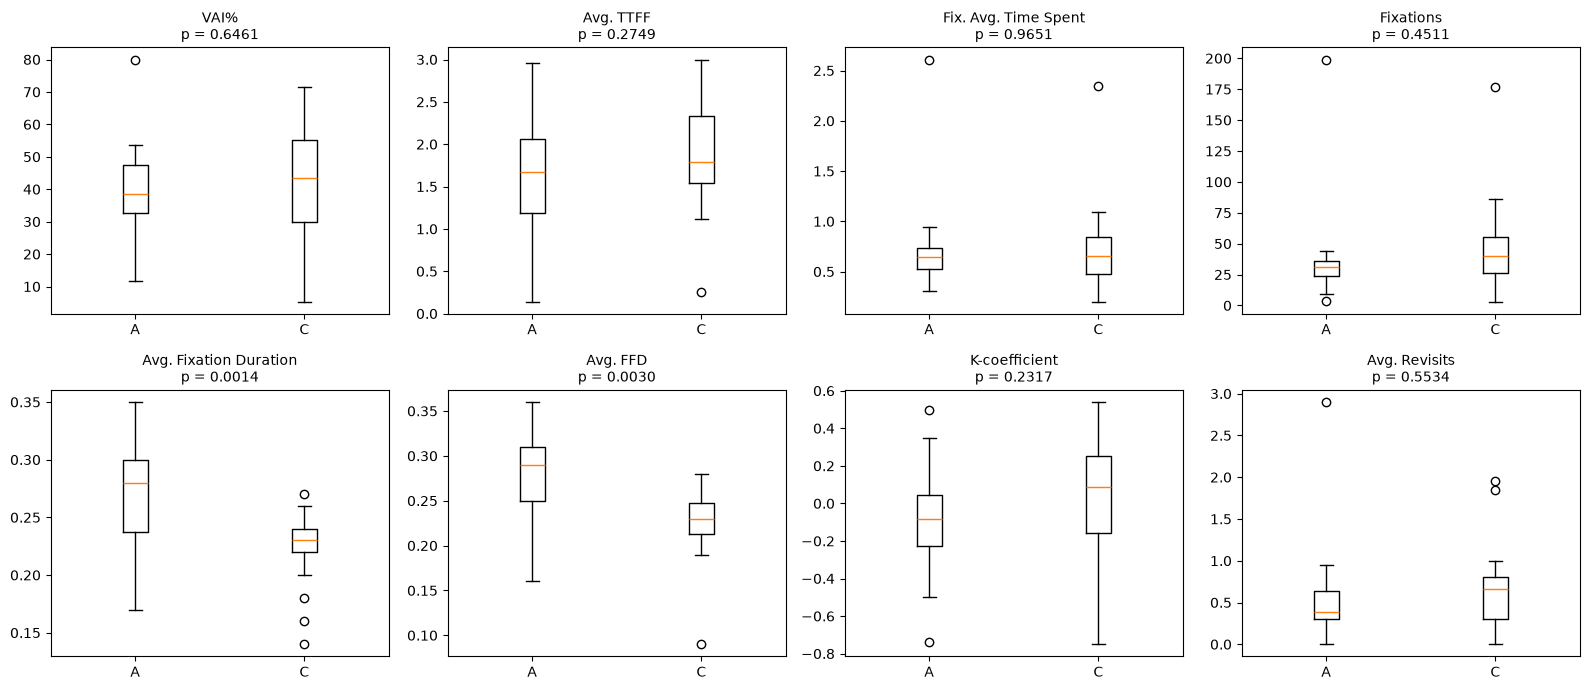

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, m in zip(axes.ravel(), metrics):
    ax.boxplot([a[m].dropna(), c[m].dropna()])
    ax.set_xticklabels(["A", "C"])
    p = results.loc[results["metric"] == m, "p"].iloc[0]
    ax.set_title(f"{m}\np = {p:.4f}", fontsize=10)
plt.tight_layout()
plt.show()